In [1]:
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import friedmanchisquare
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
ensemble_metrics_dir = Path("./ensemble_testing_metrics") #UY
us_ensemble_metrics_dir = Path("../extending_caravan/ensemble_metrics") #US

In [3]:
caravan_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mm_day.csv")
chirps_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day.csv")
mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mswep_mm_day.csv")
gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_gauge_mm_day.csv")
chirps_mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day.csv")
chirps_mswep_gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day.csv")

In [4]:
# caravan_metrics

In [5]:
# nse_df = pd.DataFrame({
#     'caravan':          caravan_metrics['NSE'].values,
#     'chirps':           chirps_metrics['NSE'].values,
#     'mswep':            mswep_metrics['NSE'].values,
#     'gauge':            gauge_metrics['NSE'].values,
#     'chirps_mswep':     chirps_mswep_metrics['NSE'].values,
#     'chirps_mswep_gauge': chirps_mswep_gauge_metrics['NSE'].values,
# }, index=caravan_metrics['basin_id'])  # use basin as index

# nse_df

In [6]:
def build_metric_df(dataframes, names, metric, index_col='basin_id'):
    return pd.DataFrame(
        {name: df[metric].values for name, df in zip(names, dataframes)},
        index=dataframes[0][index_col]
    )

# Define once
dfs   = [caravan_metrics, chirps_metrics, mswep_metrics, 
         gauge_metrics, chirps_mswep_metrics, chirps_mswep_gauge_metrics]
names = ['caravan', 'chirps', 'mswep', 
         'gauge', 'chirps_mswep', 'chirps_mswep_gauge']

# Build for each metric
nse_df  = build_metric_df(dfs, names, 'NSE')
rmse_df = build_metric_df(dfs, names, 'RMSE')
mse_df  = build_metric_df(dfs, names, 'MSE')
kge_df  = build_metric_df(dfs, names, 'Beta-KGE')
fhv_df  = build_metric_df(dfs, names, 'FHV')
fms_df  = build_metric_df(dfs, names, 'FMS')
flv_df  = build_metric_df(dfs, names, 'FLV')
peak_timing_df  = build_metric_df(dfs, names, 'Peak-Timing')
missed_peaks_df  = build_metric_df(dfs, names, 'Missed-Peaks')
peak_mape_df  = build_metric_df(dfs, names, 'Peak-MAPE')

def shapiro_test(df, metric_name):
    print(f"\nShapiro-Wilk — {metric_name}")
    print("=" * 45)
    for model in df.columns:
        stat, p = stats.shapiro(df[model])
        normal = "Normal" if p > 0.05 else "Non-normal"
        print(f"{model:20s}  W={stat:.4f}  p={p:.4f}  {normal}")

shapiro_test(nse_df,         'NSE')
shapiro_test(rmse_df,        'RMSE')
shapiro_test(mse_df,         'MSE')
shapiro_test(kge_df,         'Beta-KGE')  # kge_df → Beta-KGE
shapiro_test(fhv_df,         'FHV')       # fhv_df → FHV
shapiro_test(fms_df,         'FMS')       # fms_df → FMS
shapiro_test(flv_df,         'FLV')
shapiro_test(peak_timing_df, 'Peak-Timing')
shapiro_test(missed_peaks_df,'Missed-Peaks')
shapiro_test(peak_mape_df,   'Peak-MAPE')


Shapiro-Wilk — NSE
caravan               W=0.9778  p=0.9525  Normal
chirps                W=0.9451  p=0.6112  Normal
mswep                 W=0.9645  p=0.8354  Normal
gauge                 W=0.9272  p=0.4209  Normal
chirps_mswep          W=0.9328  p=0.4761  Normal
chirps_mswep_gauge    W=0.9155  p=0.3210  Normal

Shapiro-Wilk — RMSE
caravan               W=0.9402  p=0.5555  Normal
chirps                W=0.9158  p=0.3229  Normal
mswep                 W=0.9316  p=0.4641  Normal
gauge                 W=0.8923  p=0.1800  Normal
chirps_mswep          W=0.9562  p=0.7415  Normal
chirps_mswep_gauge    W=0.9242  p=0.3936  Normal

Shapiro-Wilk — MSE
caravan               W=0.9185  p=0.3444  Normal
chirps                W=0.9070  p=0.2611  Normal
mswep                 W=0.9476  p=0.6406  Normal
gauge                 W=0.9056  p=0.2524  Normal
chirps_mswep          W=0.9615  p=0.8025  Normal
chirps_mswep_gauge    W=0.9418  p=0.5737  Normal

Shapiro-Wilk — Beta-KGE
caravan               W=0.8877  

# US (CHIRPS_v2 or CHIRPS_v3)

In [7]:
# US
run_metrics = ['camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CAMELS
               "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
               # 'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS
               'chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS_v3
               'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP
               # 'mswep_precipitation_chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS
               'mswep_precipitation_chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS_v3
               ] 

In [8]:
model_labels = [
    'camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep'
]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [9]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(us_ensemble_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    for metric in metric_names:
        all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [10]:
# ── Friedman test ─────────────────────────────────────────────────────────────
def friedman_test(df, metric_name):
    data = [df[col].dropna().values for col in df.columns]
    stat, p = friedmanchisquare(*data)

    k = len(df.columns)
    n = len(df)
    W = stat / (n * (k - 1))

    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"

    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²           = {stat:.4f}")
    print(f"  p-value      = {p:.4f}")
    print(f"  Kendall W    = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")

    return stat, p, W

In [11]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 317.8753
  p-value      = 0.0000
  Kendall W    = 0.5160 (large effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 393.7506
  p-value      = 0.0000
  Kendall W    = 0.6392 (large effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 176.2280
  p-value      = 0.0000
  Kendall W    = 0.2861 (small effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FLV
  χ²           = 67.4127
  p-value      = 0.0000
  Kendall W    = 0.1094 (small effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 149.4701
  p-value      = 0.0000
  Kendall W    = 0.2426 (small effect)
  n catchments = 154, k models = 5

  Significant difference between m

In [12]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(1.5073045988258034e-67),
 'Missed-Peaks': np.float64(6.230702679640946e-84),
 'Peak-Timing': np.float64(4.814068079107706e-37),
 'FLV': np.float64(7.978513900229984e-14),
 'FMS': np.float64(2.644056286436193e-31),
 'FHV': np.float64(1.3247618571002888e-16),
 'MSE': np.float64(8.249299501176194e-88),
 'RMSE': np.float64(8.249299501176194e-88),
 'NSE': np.float64(8.249299501176194e-88),
 'Mean ratio': np.float64(1.3308956090148348e-15)}

In [13]:
metric_targets = {
    'Peak-MAPE': 0,
    'Missed-Peaks': 0,
    'Peak-Timing': 0,
    'FLV': 0,
    'FMS': 0,
    'FHV': 0,
    'Mean ratio': 1,   # ← updated here
    'MSE': 0,
    'RMSE': 0,
    'NSE': 1
}

In [14]:
def posthoc_wilcoxon(df, metric_name, friedman_p, metric_targets):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs  = list(itertools.combinations(models, 2))
    target = metric_targets[metric_name]
    
    rows = []
    for m1, m2 in pairs:
        diff      = df[m1].values - df[m2].values
        n_zeros   = (diff == 0).sum()
        n_effective = len(diff) - n_zeros

        if n_zeros > 0:
            print(f"  ⚠️  {metric_name} | {m1} vs {m2}: "
                  f"{n_zeros} tied pairs dropped (n_effective={n_effective})")

        stat, p_raw    = wilcoxon(df[m1].values, df[m2].values)
        median_diff    = np.median(diff)          # >0 → m1 tends higher, <0 → m2 tends higher
        median_m1      = df[m1].median()
        median_m2      = df[m2].median()

        # Direction: which model is closer to the target?
        # if abs(median_m1 - target) < abs(median_m2 - target):
        #     better = m1
        # elif abs(median_m2 - target) < abs(median_m1 - target):
        #     better = m2
        # else:
        #     better = 'tie'

        # Direction:
        dist_m1 = abs(median_m1 - target)
        dist_m2 = abs(median_m2 - target)

        if dist_m1 < dist_m2:
            better = m1
        elif dist_m2 < dist_m1:
            better = m2
        else:
            better = 'tie'

        rows.append({
            'model_1':      m1,
            'model_2':      m2,
            'median_m1':    median_m1,
            'median_m2':    median_m2,
            'median_diff':  median_diff,
            'better':       better,
            'p_raw':        p_raw,
            'n_zeros':      n_zeros,
            'n_effective':  n_effective,
        })
    
    results_df = pd.DataFrame(rows)
    
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05

    print(f"\n{'='*80}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}  (target = {target})")
    print(f"{'='*80}")
    for _, row in results_df.iterrows():
        if row['significant']:
            sig = f"* {row['better']} better"
        else:
            sig = "  similar"
        zeros = f"  [⚠️  {int(row['n_zeros'])} ties]" if row['n_zeros'] > 0 else ""
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"med=({row['median_m1']:.3f} | {row['median_m2']:.3f})  "
              f"p_adj={row['p_corrected']:.4f}  {sig}{zeros}")
    
    return results_df


# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  camels               vs caravan               med=(43.966 | 64.181)  p_adj=0.0000  * camels better
  camels               vs chirps                med=(43.966 | 51.239)  p_adj=0.0000  * camels better
  camels               vs mswep                 med=(43.966 | 43.150)  p_adj=0.1982    similar
  camels               vs chirps_mswep          med=(43.966 | 42.541)  p_adj=0.2090    similar
  caravan              vs chirps                med=(64.181 | 51.239)  p_adj=0.0000  * chirps better
  caravan              vs mswep                 med=(64.181 | 43.150)  p_adj=0.0000  * mswep better
  caravan              vs chirps_mswep          med=(64.181 | 42.541)  p_adj=0.0000  * chirps_mswep better
  chirps               vs mswep                 med=(51.239 | 43.150)  p_adj=0.0000  * mswep better
  chirps               vs chirps_mswep          med=(51.239 | 42.541)  p_adj=0.0000  * chirps_mswep better
  mswep                vs chir

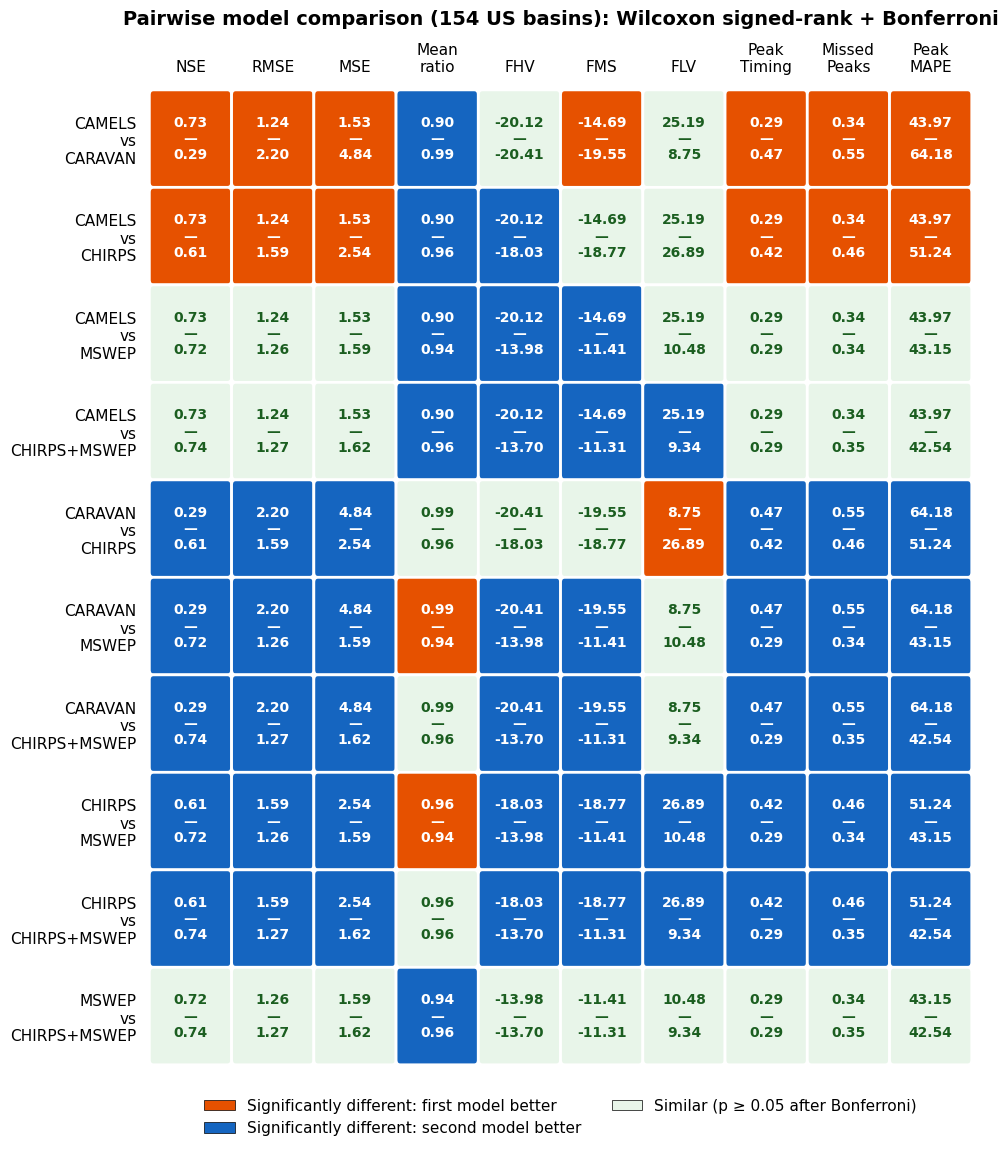

In [15]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep']
short_names = ['CAMELS', 'CARAVAN', 'CHIRPS', 'MSWEP', 'CHIRPS+MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))
pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(pairs)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(metrics_list_names)))
ax.set_yticklabels(pair_labels, fontsize=11) 
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    # mpatches.Patch(color=colors[2],        label='Not tested (Friedman n.s.)'),
]

ax.set_title(
    'Pairwise model comparison (154 US basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()

# UY

## CARAVAN, CHIRPS, MSWEP, GAUGE, CHIRPS + MSWWEP

In [16]:
# UY
run_metrics = ['precip_prcp_mm_day', #CARAVAN
               'precip_prcp_chirps_mm_day', #CHIRPS_v3
               'precip_prcp_mswep_mm_day', #MSWEP
               'precip_prcp_gauge_mm_day', #GAUGES
               'precip_prcp_chirps_mm_day_prcp_mswep_mm_day' #MSWEP + CHIRPS_v3
               ] 

In [17]:
model_labels = [
    'caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep'
]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [18]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    for metric in metric_names:
        all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [19]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 24.6400
  p-value      = 0.0001
  Kendall W    = 0.6160 (large effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 21.9067
  p-value      = 0.0002
  Kendall W    = 0.5477 (large effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 10.5918
  p-value      = 0.0316
  Kendall W    = 0.2648 (small effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FLV
  χ²           = 9.9200
  p-value      = 0.0418
  Kendall W    = 0.2480 (small effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 28.4000
  p-value      = 0.0000
  Kendall W    = 0.7100 (large effect)
  n catchments = 10, k models = 5

  Significant difference between models (p <

In [20]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(5.942869693415439e-05),
 'Missed-Peaks': np.float64(0.00020917176396307232),
 'Peak-Timing': np.float64(0.0315552020105126),
 'FLV': np.float64(0.04179704988220884),
 'FMS': np.float64(1.0348131642844003e-05),
 'FHV': np.float64(2.8306820708071368e-05),
 'MSE': np.float64(0.0001289774935977151),
 'RMSE': np.float64(0.0001289774935977151),
 'NSE': np.float64(0.0001289774935977151),
 'Mean ratio': np.float64(0.00027865041414443324)}

In [21]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(56.785 | 44.435)  p_adj=0.0195  * chirps better
  caravan              vs mswep                 med=(56.785 | 46.146)  p_adj=0.0195  * mswep better
  caravan              vs gauge                 med=(56.785 | 41.554)  p_adj=0.0391  * gauge better
  caravan              vs chirps_mswep          med=(56.785 | 39.352)  p_adj=0.0195  * chirps_mswep better
  chirps               vs mswep                 med=(44.435 | 46.146)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(44.435 | 41.554)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(44.435 | 39.352)  p_adj=0.0391  * chirps_mswep better
  mswep                vs gauge                 med=(46.146 | 41.554)  p_adj=1.0000    similar
  mswep                vs chirps_mswep          med=(46.146 | 39.352)  p_adj=0.0195  * chirps_mswep better
  gauge                vs chir

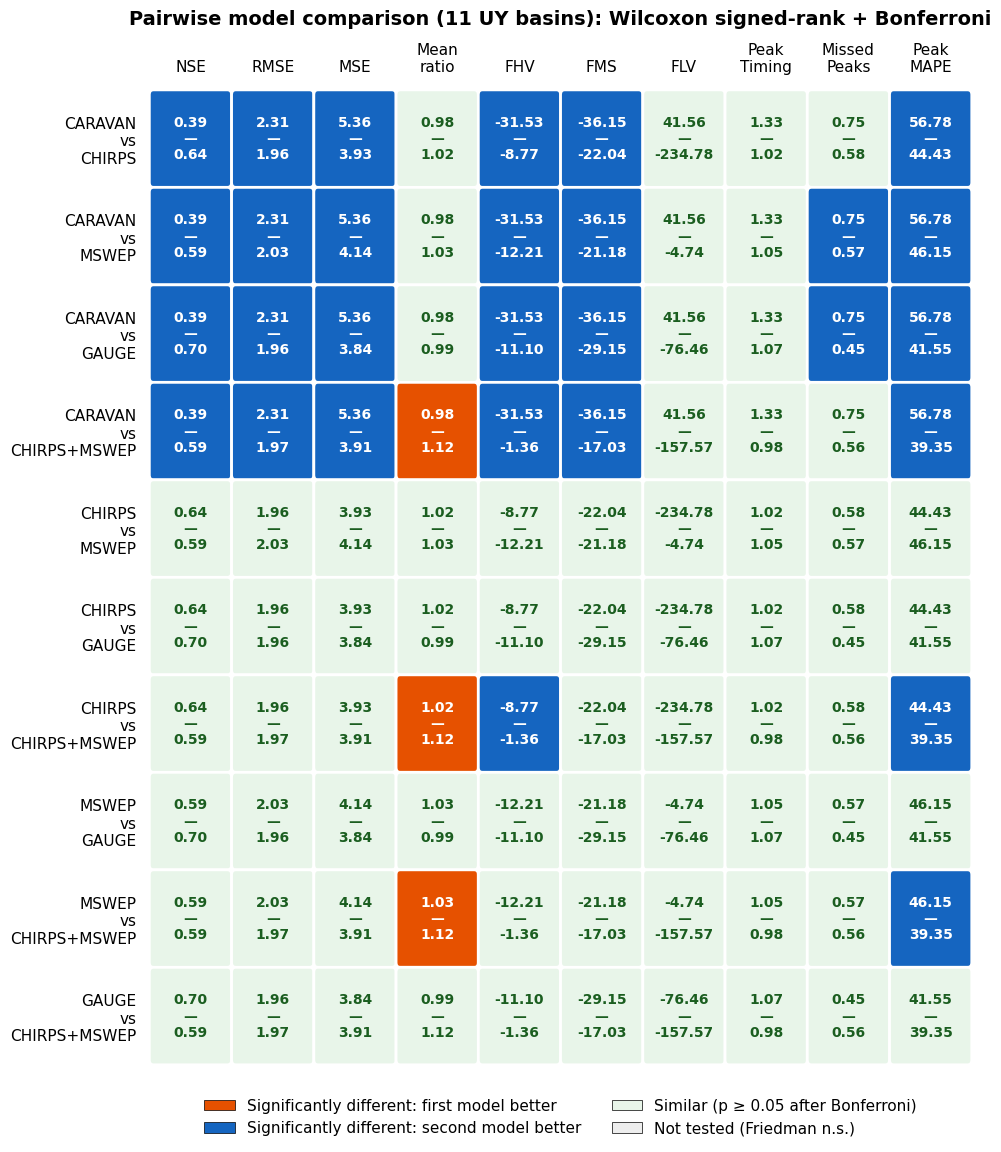

In [22]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))
pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))         
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested (Friedman n.s.)', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()

# CHIRPS + MSWEP + GAUGE

In [23]:
# UY
run_metrics = ['precip_prcp_mm_day', #CARAVAN
               'precip_prcp_chirps_mm_day', #CHIRPS_v3
               'precip_prcp_mswep_mm_day', #MSWEP
               'precip_prcp_gauge_mm_day', #GAUGES
               'precip_prcp_chirps_mm_day_prcp_mswep_mm_day', #MSWEP + CHIRPS_v3
               'precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day' #CHIRPS + MSWEP + GAUGES
               ] 

In [24]:
model_labels = [
    'caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge'
]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [25]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    for metric in metric_names:
        all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [26]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 30.6857
  p-value      = 0.0000
  Kendall W    = 0.6137 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 25.9118
  p-value      = 0.0001
  Kendall W    = 0.5182 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 13.7865
  p-value      = 0.0170
  Kendall W    = 0.2757 (small effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FLV
  χ²           = 14.1143
  p-value      = 0.0149
  Kendall W    = 0.2823 (small effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 26.9714
  p-value      = 0.0001
  Kendall W    = 0.5394 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p 

In [27]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(1.080526991757693e-05),
 'Missed-Peaks': np.float64(9.282159986713695e-05),
 'Peak-Timing': np.float64(0.017023667113242002),
 'FLV': np.float64(0.014899525669135235),
 'FMS': np.float64(5.777790325543697e-05),
 'FHV': np.float64(1.025860873923187e-05),
 'MSE': np.float64(1.3296718258731084e-05),
 'RMSE': np.float64(1.3296718258731084e-05),
 'NSE': np.float64(1.3296718258731084e-05),
 'Mean ratio': np.float64(3.119056536341855e-05)}

In [28]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(56.785 | 44.435)  p_adj=0.0293  * chirps better
  caravan              vs mswep                 med=(56.785 | 46.146)  p_adj=0.0293  * mswep better
  caravan              vs gauge                 med=(56.785 | 41.554)  p_adj=0.0586    similar
  caravan              vs chirps_mswep          med=(56.785 | 39.352)  p_adj=0.0293  * chirps_mswep better
  caravan              vs chirps_mswep_gauge    med=(56.785 | 39.042)  p_adj=0.0293  * chirps_mswep_gauge better
  chirps               vs mswep                 med=(44.435 | 46.146)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(44.435 | 41.554)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(44.435 | 39.352)  p_adj=0.0586    similar
  chirps               vs chirps_mswep_gauge    med=(44.435 | 39.042)  p_adj=0.4102    similar
  mswep                vs gauge          

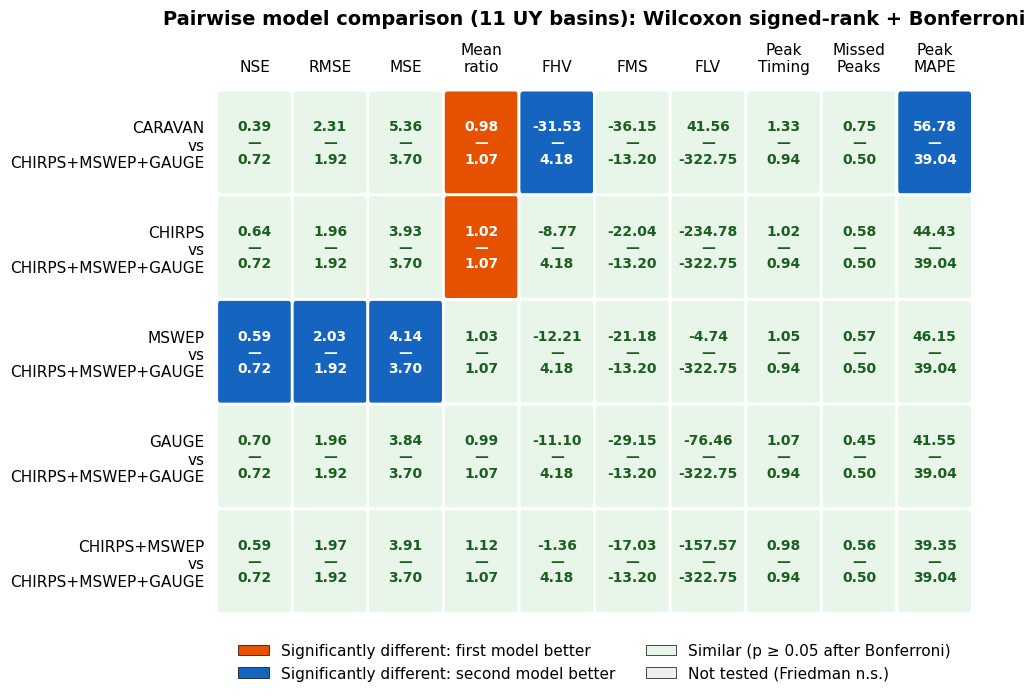

In [29]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP', 'CHIRPS+MSWEP+GAUGE']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))

# Keep only pairs involving chirps_mswep_gauge
gauge_idx = models.index('chirps_mswep_gauge')
pairs = [(i, j) for i, j in pairs if i == gauge_idx or j == gauge_idx]

pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]


pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))        
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested (Friedman n.s.)', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()